In [ ]:
Name:Ashif Hussain
Subject:Generative AI
ASSIGNMENT:01
Topic:Understanding Generative and Discriminative Models Using MNIST


In [ ]:
#Step 1 - Import the dataset tool
# Import the MNIST dataset from Keras

from tensorflow.keras.datasets import mnist

In [ ]:
#Step 2 - Load the data
# Load the digit images and their correct answers (labels)
# x_train/x_test = images, y_train/y_test = correct digit labels

(x_train, y_train), (x_test, y_test) = mnist.load_data()

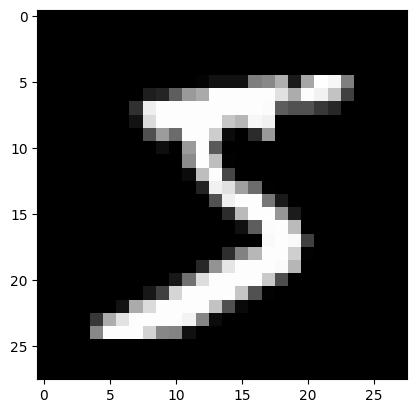

In [ ]:
#Step 3 - View one image

# Import tool to draw images
import matplotlib.pyplot as plt

# Show the first image from the training data in black and white
plt.imshow(x_train[0], cmap='gray')
plt.show()

In [ ]:
#Step 4 - Keep only digit 0 and 1 (training data)

# Check which training labels are 0 or 1
train_filter = (y_train == 0) | (y_train == 1)

# Keep only those images and labels
x_train = x_train[train_filter]
y_train = y_train[train_filter]

In [ ]:
#Step 5 - Keep only digit 0 and 1 (test data)

# Do the same filtering for the test data
test_filter = (y_test == 0) | (y_test == 1)
x_test = x_test[test_filter]
y_test = y_test[test_filter]

# Print how many images we have left, to confirm it worked
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (12665, 28, 28)
Testing images: (2115, 28, 28)


In [ ]:
#Step 6 - Scale pixel values

# Change pixel values from 0-255 range to 0-1 range
# This helps the model learn faster and better
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
#Step 7 - Flatten the images

# Turn each 28x28 image into one long line of 784 numbers
# This is needed for the Logistic Regression model
x_train_flat = x_train.reshape(x_train.shape[0], 28*28)
x_test_flat = x_test.reshape(x_test.shape[0], 28*28)

In [ ]:
#Step 8 - Build and train the discriminative model

# Import Logistic Regression, a simple classification model
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression()

# Train the model using training images and their correct labels
model.fit(x_train_flat, y_train)

LogisticRegression()

In [ ]:
#Step 9 - Check accuracy

# Test the model on images it has never seen before
# and calculate how many it gets correct
accuracy = model.score(x_test_flat, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9995271867612293


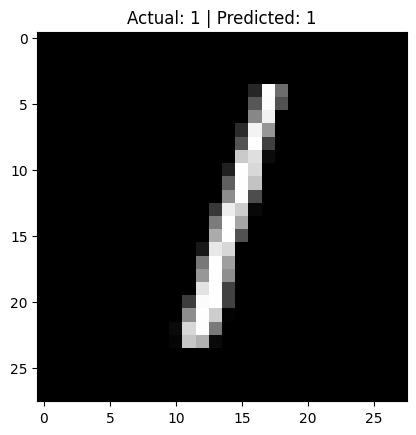

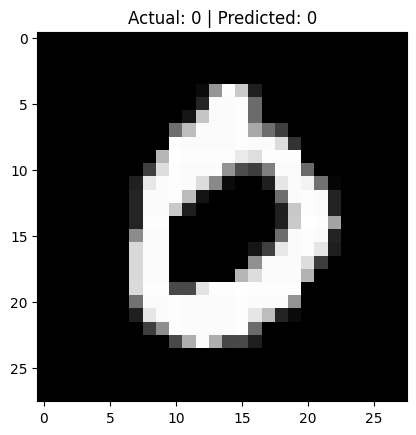

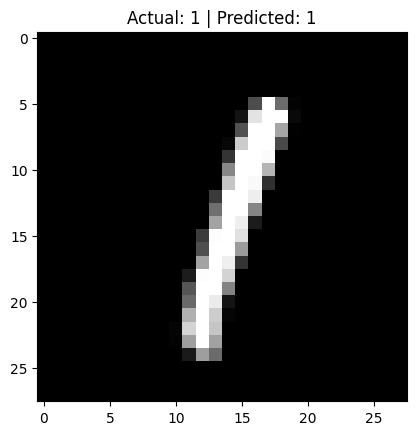

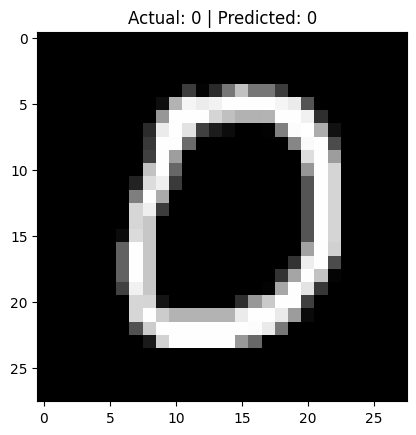

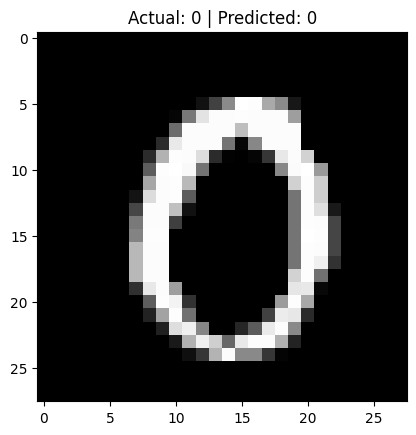

In [ ]:
#Step 10 - Look at predictions

# Ask the model to guess the digit for every test image
predictions = model.predict(x_test_flat)

# Show the first 5 test images with actual label vs predicted label
for i in range(5):
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Actual: " + str(y_test[i]) + " | Predicted: " + str(predictions[i]))
    plt.show()

In [ ]:
#Step 11 - Import tools for the generative model

# Import tools needed to build the autoencoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [ ]:
#Step 12 - Build the encoder and decoder

# Input layer: each image comes in as 784 numbers
input_img = Input(shape=(784,))

# Encoder: squishes the 784 numbers down to just 32 numbers (a summary)
encoded = Dense(32, activation='relu')(input_img)

# Decoder: rebuilds the full 784 numbers from the 32-number summary
decoded = Dense(784, activation='sigmoid')(encoded)

# Combine encoder and decoder into one autoencoder model
autoencoder = Model(input_img, decoded)

In [ ]:
#Step 13 - Set up training settings

# Tell the model how to learn (optimizer)
# and how to measure mistakes (loss)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
#Step 14 - Train the autoencoder

# Train the autoencoder to rebuild the same images it is given
# (input and target are the same images, no labels needed)
autoencoder.fit(x_train_flat, x_train_flat,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_flat, x_test_flat))

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.4497 - val_loss: 0.2483
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2068 - val_loss: 0.1783
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1667 - val_loss: 0.1532
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1476 - val_loss: 0.1401
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1382 - val_loss: 0.1335
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1320 - val_loss: 0.1269
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1254 - val_loss: 0.1211
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1204 - val_loss: 0.1167
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1161 - val_loss: 0.1126
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1120 - val_loss: 0.1086


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


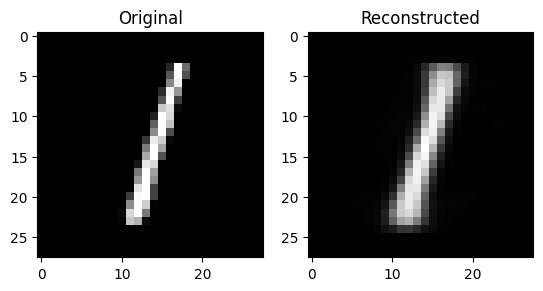

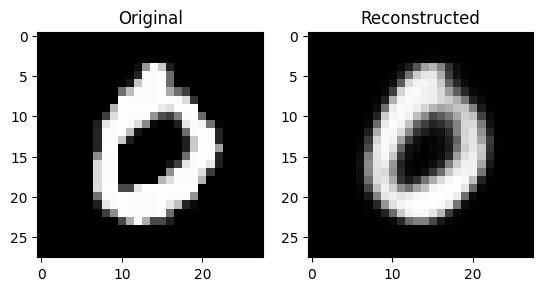

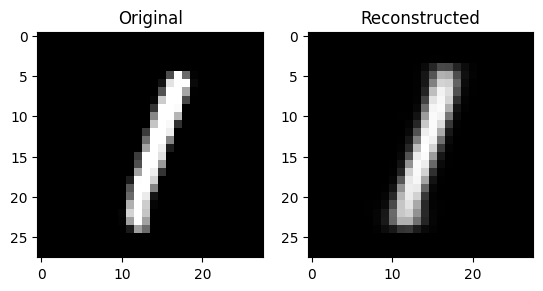

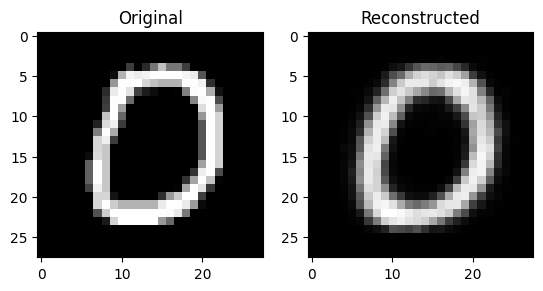

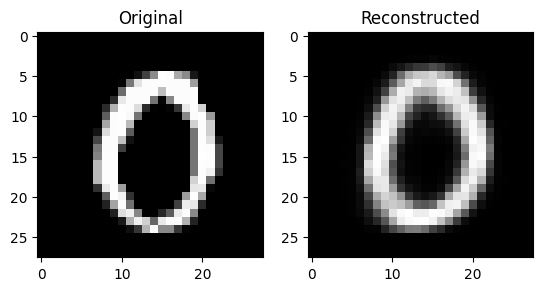

In [ ]:
#Step 15 - See reconstructed images

# Ask the autoencoder to rebuild the test images
reconstructed = autoencoder.predict(x_test_flat)

# Show original image next to the rebuilt image, for 5 examples
for i in range(5):
    plt.subplot(1, 2, 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")

    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")

    plt.show()

In [ ]:
#Step 16 - Create random numbers

import numpy as np

# Create 5 sets of 32 random numbers
# (pretend "summaries" of images that don't really exist)
random_latent = np.random.rand(5, 32)

In [ ]:
#Step 17 - Extract just the decoder

# Build a separate model using only the decoder part
encoding_dim = 32
decoder_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(decoder_input, decoder_layer(decoder_input))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


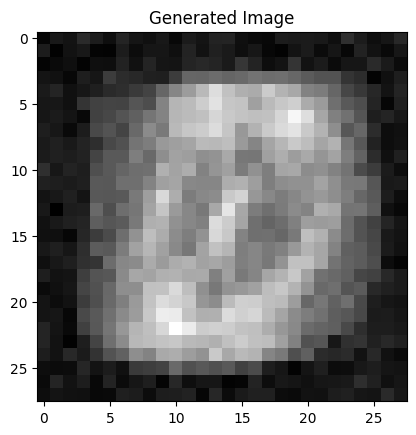

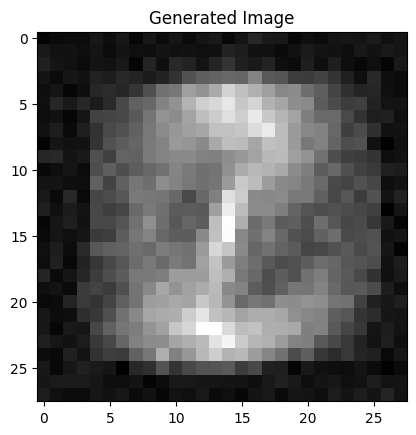

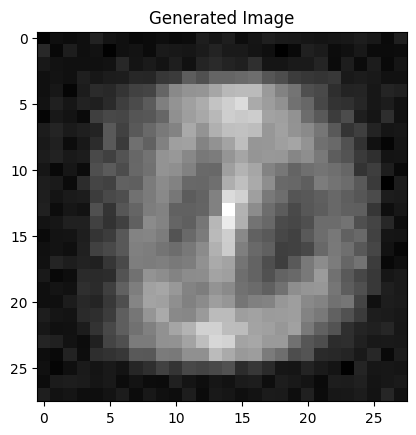

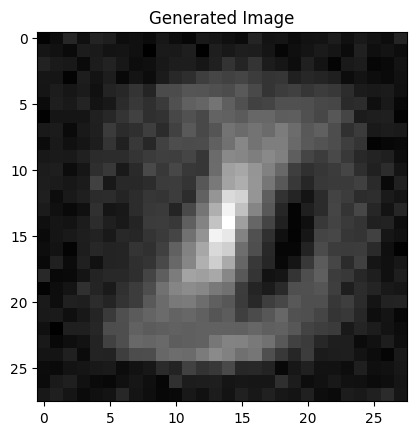

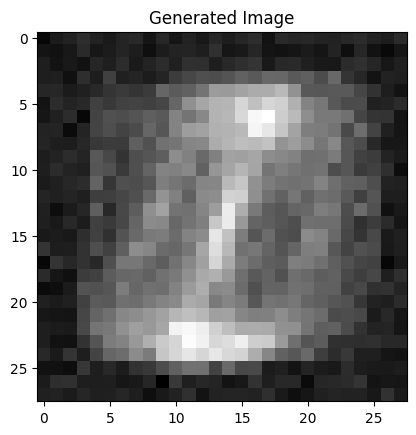

In [ ]:
#Step 18 - Generate new digit images

# Feed random numbers into the decoder to create new images
generated_images = decoder.predict(random_latent)

# Show each generated image
for i in range(5):
    plt.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    plt.title("Generated Image")
    plt.show()

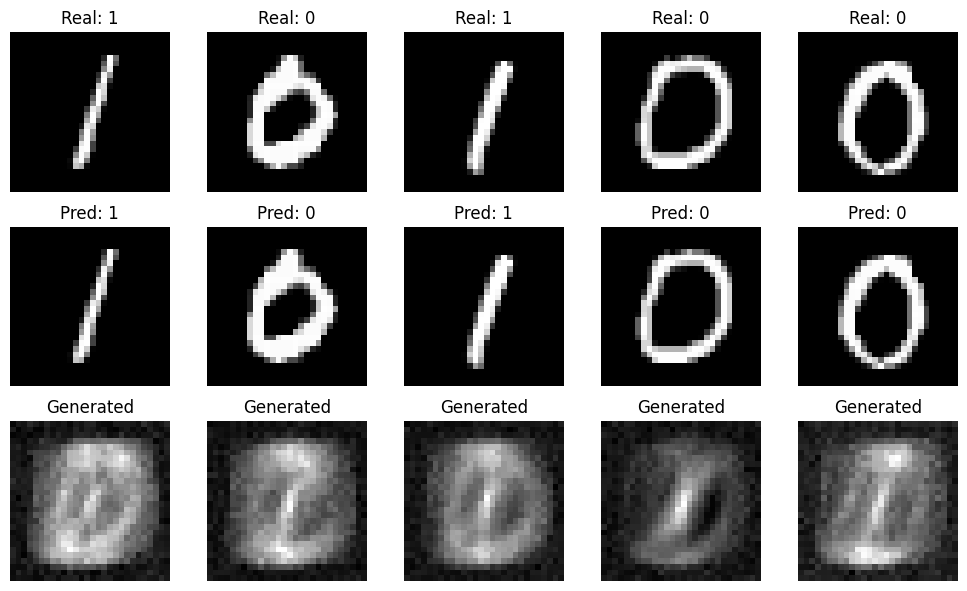

In [ ]:
#Step 19 - Full comparison plot

plt.figure(figsize=(10, 6))

for i in range(5):
    # Row 1: Real images
    plt.subplot(3, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Real: " + str(y_test[i]))
    plt.axis('off')

    # Row 2: Discriminative model's predictions
    plt.subplot(3, 5, i+6)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Pred: " + str(predictions[i]))
    plt.axis('off')

    # Row 3: Generated images
    plt.subplot(3, 5, i+11)
    plt.imshow(generated_images[i].reshape(28, 28), cmap='gray')
    plt.title("Generated")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [59]:
Written Reflection

1.What did the discriminative model learn?

The discriminative model (Logistic Regression) learned to find a boundary that separates digit 0 from digit 1.
It looked at the pixel patterns in each image and figured out which patterns usually belong to a 0 and which usually belong to a 1.
It does not learn what a digit actually looks like as a whole, it only learns how to tell the two classes apart.
Because 0 and 1 look quite different from each other, this was an easy task, and the model reached a high accuracy of 99.95 percent.

2.What did the generative model learn?

The generative model (Autoencoder) learned the overall structure and pattern of how digits 0 and 1 are drawn.
It did not use any labels at all. Instead, it learned by compressing each image into a small summary and
then trying to rebuild the full image from that summary. Through this process, it picked up the general shape, curves,
and structure that make up a 0 or a 1.This is also why it was able to generate new digit-like images using random summary numbers,
since it had learned the overall pattern of the data, not just a boundary.

3.How are the two approaches different?

The discriminative model focuses on classification, meaning it learns to separate data into groups using labels.
It is only good at telling classes apart, not at understanding or recreating the data itself.
The generative model focuses on understanding the data deeply enough to recreate it and even produce new similar examples,
without needing any labels. In short, the discriminative model learns a decision boundary between classes,
while the generative model learns the underlying distribution or structure of the data itself.







